# 03 — SQL Business Analysis
### Olist Brazilian E-Commerce — Delivery & Review Risk Analysis

**Business question:** What's driving late deliveries and poor reviews, and how much revenue is at risk because of it?

Notebook 2 built a clean, validated master table (`master_orders_sql`) plus the raw tables in `olist.db`. This notebook runs the actual investigative queries against them:

1. Top sellers by late-delivery rate (ranking window function)
2. Revenue at risk from 1–2 star orders
3. Late-delivery rate and review score by product category
4. Delivery time vs. review score by state
5. Month-over-month late-delivery trend (`LAG` window function)
6. Ranked root causes: worst state × category combinations
7. A single bottom-line revenue-at-risk figure


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

DB_PATH = '../Data/processed/olist.db'
conn = sqlite3.connect(DB_PATH)
print('Connected to', DB_PATH)


Connected to ../Data/processed/olist.db


## 1. Top 10 sellers by late-delivery rate
Ranking sellers by late rate alone would let a seller with 2 orders (both late) outrank one with 500 — so this filters to sellers with at least 20 delivered orders first, then ranks with `RANK() OVER (ORDER BY late_rate DESC)`.

In [2]:
top_late_sellers = pd.read_sql("""
    WITH seller_orders AS (
        SELECT
            oi.seller_id,
            m.order_id,
            m.is_late,
            m.order_revenue
        FROM order_items oi
        JOIN master_orders_sql m ON oi.order_id = m.order_id
        WHERE m.is_delivered = 1
        GROUP BY oi.seller_id, m.order_id
    ),
    seller_stats AS (
        SELECT
            seller_id,
            COUNT(*) AS n_delivered_orders,
            SUM(is_late) AS n_late_orders,
            ROUND(100.0 * SUM(is_late) / COUNT(*), 1) AS late_rate_pct,
            ROUND(SUM(CASE WHEN is_late = 1 THEN order_revenue ELSE 0 END), 2) AS revenue_on_late_orders
        FROM seller_orders
        GROUP BY seller_id
        HAVING COUNT(*) >= 20
    )
    SELECT
        seller_id,
        n_delivered_orders,
        n_late_orders,
        late_rate_pct,
        revenue_on_late_orders,
        RANK() OVER (ORDER BY late_rate_pct DESC) AS late_rate_rank
    FROM seller_stats
    ORDER BY late_rate_pct DESC
    LIMIT 10
""", conn)
top_late_sellers


,seller_id,n_delivered_orders,n_late_orders,late_rate_pct,revenue_on_late_orders,late_rate_rank
0,821fb029fc6e495ca4f08a35d51e53a5,24,9,37.5,3983.70,1
1,f76a3b1349b6df1ee875d1f3fa4340f0,24,9,37.5,1666.30,1
2,ede0c03645598cdfc63ca8237acbe73d,43,15,34.9,904.04,3
3,ad781527c93d00d89a11eecd9dcad7c1,38,12,31.6,2511.61,4
4,835f0f7810c76831d6c7d24c7a646d4d,42,13,31.0,1893.08,5
5,54965bbe3e4f07ae045b90b0b8541f52,73,22,30.1,4009.33,6
6,054694fa03fe82cec4b7551487331d74,20,6,30.0,2512.49,7
7,7f152321c60a266edc53af1925ef96c1,20,6,30.0,1560.76,7
8,4e5725ba188db8252977a4f0227bd462,21,6,28.6,396.31,9
9,2a1348e9addc1af5aaa619b1a3679d6b,48,13,27.1,1117.86,10


## 2. Revenue at risk from low-rated (1–2 star) orders

In [3]:
revenue_at_risk = pd.read_sql("""
    WITH totals AS (
        SELECT SUM(order_revenue) AS total_revenue
        FROM master_orders_sql
        WHERE is_delivered = 1 AND order_revenue IS NOT NULL
    ),
    low_rated AS (
        SELECT SUM(order_revenue) AS low_rated_revenue, COUNT(*) AS n_low_rated_orders
        FROM master_orders_sql
        WHERE is_delivered = 1 AND review_score <= 2
    )
    SELECT
        low_rated.n_low_rated_orders,
        ROUND(low_rated.low_rated_revenue, 2) AS revenue_from_low_rated_orders,
        ROUND(totals.total_revenue, 2) AS total_revenue,
        ROUND(100.0 * low_rated.low_rated_revenue / totals.total_revenue, 2) AS pct_revenue_at_risk
    FROM low_rated, totals
""", conn)
revenue_at_risk


,n_low_rated_orders,revenue_from_low_rated_orders,total_revenue,pct_revenue_at_risk
0,12273,2302310.28,15419773.75,14.93


## 3. Late-delivery rate and review score by product category
Which categories combine high late-delivery rates with low review scores — and how much revenue sits behind each.

In [4]:
category_stats = pd.read_sql("""
    SELECT
        COALESCE(main_category, 'unknown') AS category,
        COUNT(*) AS n_orders,
        ROUND(100.0 * SUM(is_late) / COUNT(*), 1) AS late_rate_pct,
        ROUND(AVG(review_score), 2) AS avg_review_score,
        ROUND(SUM(order_revenue), 2) AS category_revenue
    FROM master_orders_sql
    WHERE is_delivered = 1
    GROUP BY category
    HAVING COUNT(*) >= 100
    ORDER BY late_rate_pct DESC
    LIMIT 15
""", conn)
category_stats


,category,n_orders,late_rate_pct,avg_review_score,category_revenue
0,audio,344,13.1,3.85,55628.41
1,fashion_underwear_beach,117,12.8,4.01,11160.02
2,books_technical,254,11.0,4.42,22894.36
3,home_confort,370,10.3,3.91,67291.40
4,food,436,10.1,4.34,35447.83
5,electronics,2502,9.9,4.13,200900.45
6,christmas_supplies,124,9.7,4.11,11882.19
7,construction_tools_construction,724,9.3,4.15,162193.18
8,baby,2761,9.3,4.12,467787.58
9,office_furniture,1251,9.2,3.65,336261.18


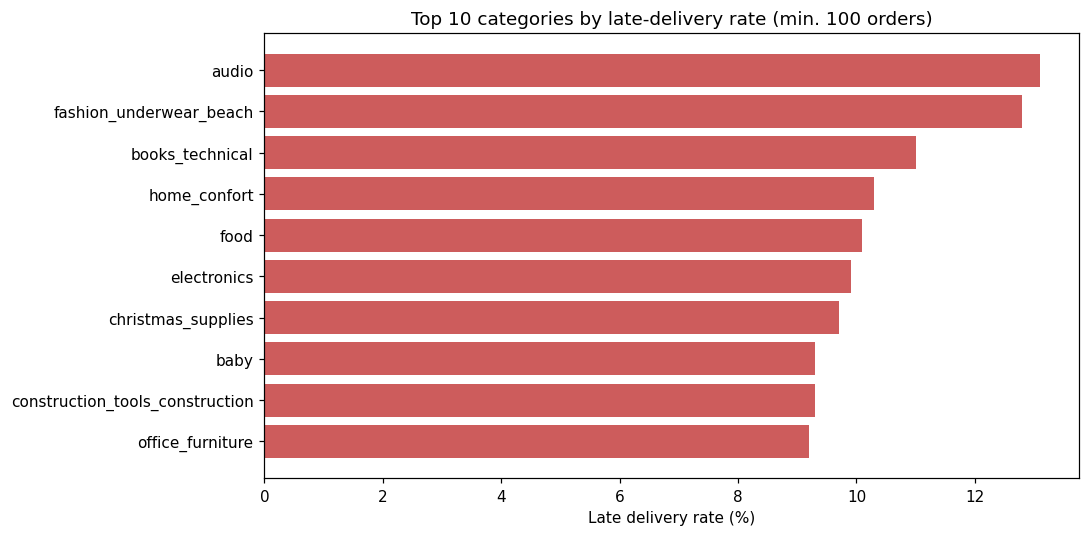

In [5]:
fig, ax1 = plt.subplots(figsize=(10, 5))
top10 = category_stats.head(10).sort_values('late_rate_pct')
ax1.barh(top10['category'], top10['late_rate_pct'], color='indianred')
ax1.set_xlabel('Late delivery rate (%)')
ax1.set_title('Top 10 categories by late-delivery rate (min. 100 orders)')
plt.tight_layout()
plt.show()


## 4. Delivery time vs. review score, by state
Do customers in slower-shipping states actually leave worse reviews, or is the relationship weaker than assumed?

In [6]:
state_stats = pd.read_sql("""
    SELECT
        customer_state,
        COUNT(*) AS n_orders,
        ROUND(AVG(delivery_time_days), 1) AS avg_delivery_days,
        ROUND(100.0 * SUM(is_late) / COUNT(*), 1) AS late_rate_pct,
        ROUND(AVG(review_score), 2) AS avg_review_score
    FROM master_orders_sql
    WHERE is_delivered = 1
    GROUP BY customer_state
    HAVING COUNT(*) >= 100
    ORDER BY avg_delivery_days DESC
""", conn)
state_stats


,customer_state,n_orders,avg_delivery_days,late_rate_pct,avg_review_score
0,AM,145,26.4,4.1,4.24
1,AL,397,24.5,23.9,3.85
2,PA,946,23.8,12.4,3.91
3,MA,717,21.6,19.7,3.83
4,SE,335,21.5,15.2,3.91
5,CE,1279,21.3,15.3,3.94
6,PB,517,20.4,11.0,4.08
7,PI,476,19.5,16.0,3.99
8,RO,243,19.4,2.9,4.17
9,RN,474,19.3,10.8,4.15


Correlation (state-level avg delivery days vs avg review score): -0.566


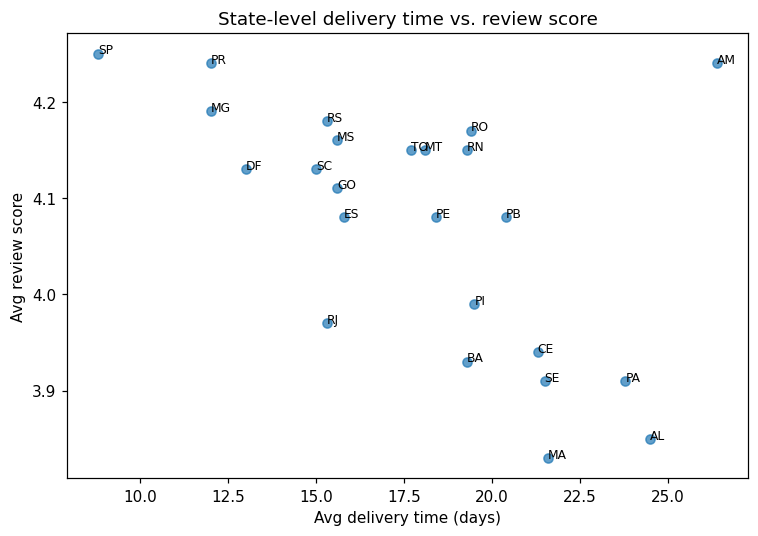

In [7]:
corr = state_stats['avg_delivery_days'].corr(state_stats['avg_review_score'])
print(f'Correlation (state-level avg delivery days vs avg review score): {corr:.3f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(state_stats['avg_delivery_days'], state_stats['avg_review_score'], alpha=0.7)
for _, row in state_stats.iterrows():
    ax.annotate(row['customer_state'], (row['avg_delivery_days'], row['avg_review_score']), fontsize=8)
ax.set_xlabel('Avg delivery time (days)')
ax.set_ylabel('Avg review score')
ax.set_title('State-level delivery time vs. review score')
plt.tight_layout()
plt.show()


## 5. Month-over-month late-delivery rate trend — `LAG` window function
Is the late-delivery problem getting better, worse, or flat over time?

In [8]:
monthly_trend = pd.read_sql("""
    WITH monthly AS (
        SELECT
            strftime('%Y-%m', order_purchase_timestamp) AS order_month,
            COUNT(*) AS n_orders,
            ROUND(100.0 * SUM(is_late) / COUNT(*), 1) AS late_rate_pct
        FROM master_orders_sql
        WHERE is_delivered = 1
        GROUP BY order_month
    )
    SELECT
        order_month,
        n_orders,
        late_rate_pct,
        LAG(late_rate_pct) OVER (ORDER BY order_month) AS prev_month_late_rate_pct,
        ROUND(late_rate_pct - LAG(late_rate_pct) OVER (ORDER BY order_month), 1) AS change_pct_pts
    FROM monthly
    WHERE n_orders >= 50
    ORDER BY order_month
""", conn)
monthly_trend


,order_month,n_orders,late_rate_pct,prev_month_late_rate_pct,change_pct_pts
0,2016-10,265,1.1,NaN,NaN
1,2017-01,750,3.1,1.1,2.0
2,2017-02,1653,3.2,3.1,0.1
3,2017-03,2546,5.6,3.2,2.4
4,2017-04,2303,7.9,5.6,2.3
5,2017-05,3546,3.6,7.9,-4.3
6,2017-06,3135,3.9,3.6,0.3
7,2017-07,3872,3.4,3.9,-0.5
8,2017-08,4193,3.3,3.4,-0.1
9,2017-09,4150,5.2,3.3,1.9


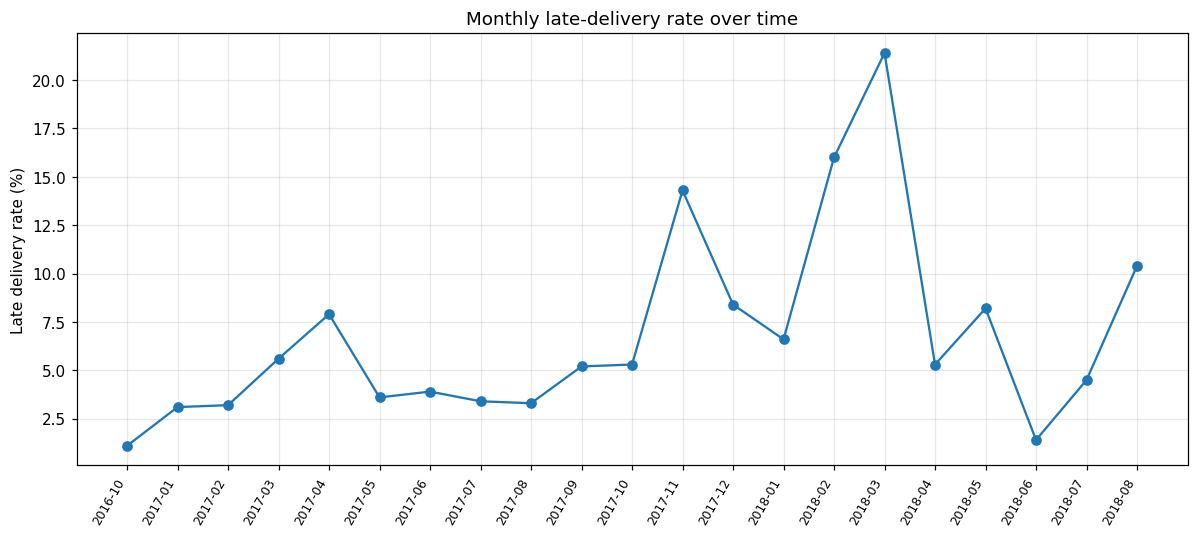

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly_trend['order_month'], monthly_trend['late_rate_pct'], marker='o')
ax.set_xticks(range(len(monthly_trend)))
ax.set_xticklabels(monthly_trend['order_month'], rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Late delivery rate (%)')
ax.set_title('Monthly late-delivery rate over time')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Ranked root causes — worst state × category combinations
Combining both dimensions surfaces specific segments (not just categories overall, or states overall) where the problem concentrates — and ranks them by revenue actually at risk, not just by rate, so the list prioritizes what's worth fixing first.

In [10]:
root_causes = pd.read_sql("""
    WITH segment AS (
        SELECT
            customer_state,
            COALESCE(main_category, 'unknown') AS category,
            COUNT(*) AS n_orders,
            SUM(is_late) AS n_late,
            ROUND(100.0 * SUM(is_late) / COUNT(*), 1) AS late_rate_pct,
            ROUND(SUM(CASE WHEN is_late = 1 THEN order_revenue ELSE 0 END), 2) AS revenue_at_risk
        FROM master_orders_sql
        WHERE is_delivered = 1
        GROUP BY customer_state, category
        HAVING COUNT(*) >= 30
    )
    SELECT
        customer_state,
        category,
        n_orders,
        late_rate_pct,
        revenue_at_risk,
        RANK() OVER (ORDER BY revenue_at_risk DESC) AS risk_rank
    FROM segment
    ORDER BY revenue_at_risk DESC
    LIMIT 15
""", conn)
root_causes


,customer_state,category,n_orders,late_rate_pct,revenue_at_risk,risk_rank
0,SP,health_beauty,3693,7.1,40237.14,1
1,SP,bed_bath_table,4307,5.1,33800.08,2
2,SP,sports_leisure,3203,5.7,29773.93,3
3,RJ,watches_gifts,784,14.8,29705.18,4
4,RJ,bed_bath_table,1342,16.6,29580.94,5
5,SP,auto,1580,7.2,28749.95,6
6,SP,watches_gifts,2085,5.8,26657.19,7
7,RJ,sports_leisure,888,15.1,24234.50,8
8,SP,housewares,2693,6.1,23076.33,9
9,SP,furniture_decor,2618,5.8,22762.88,10


## 7. Bottom-line revenue-at-risk summary

In [11]:
summary = pd.read_sql("""
    SELECT
        (SELECT ROUND(SUM(order_revenue), 2) FROM master_orders_sql WHERE is_delivered = 1) AS total_delivered_revenue,
        (SELECT ROUND(SUM(order_revenue), 2) FROM master_orders_sql WHERE is_delivered = 1 AND is_late = 1) AS revenue_on_late_orders,
        (SELECT ROUND(SUM(order_revenue), 2) FROM master_orders_sql WHERE is_delivered = 1 AND review_score <= 2) AS revenue_on_low_rated_orders,
        (SELECT ROUND(100.0 * SUM(is_late) / COUNT(*), 2) FROM master_orders_sql WHERE is_delivered = 1) AS overall_late_rate_pct
""", conn)
summary


,total_delivered_revenue,revenue_on_late_orders,revenue_on_low_rated_orders,overall_late_rate_pct
0,15419773.75,1351624.96,2302310.28,8.11


In [12]:
conn.close()
print('Connection closed. Findings persisted in olist.db / CSVs from Notebook 2 for reuse in Notebook 4.')


Connection closed. Findings persisted in olist.db / CSVs from Notebook 2 for reuse in Notebook 4.


---
**Next:** `04_conclusions_and_recommendations.ipynb` — pulling these results into a ranked list of root causes, a final revenue-at-risk headline number, and recommendations (plus optional Power BI dashboard on top, same as your churn project).
